In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# BƯỚC 1: Thu thập dữ liệu, phân tích và chọn lựa các features
# Giả lập dữ liệu điểm số của học sinh như ví dụ trước
data = {
    'diemvan': [8.0, 7.0, 4.0, 9.0, 3.5, 6.5, 5.0, 8.5, 4.5, 7.5],
    'diemtoan': [9.0, 8.0, 3.0, 9.5, 4.0, 7.0, 5.5, 8.0, 5.0, 8.5],
    'ketqua': ['Pass', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass']
}
df = pd.DataFrame(data)

# Chọn features (X) và nhãn mục tiêu (y)
X = df[['diemvan', 'diemtoan']]
y = df['ketqua']

# BƯỚC 2: Chia tập dữ liệu thành các tập cho training và testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# BƯỚC 3: Lựa chọn mô hình
# Khởi tạo mô hình KNN với số láng giềng k = 3
model_knn = KNeighborsClassifier(n_neighbors=3)

# BƯỚC 4: Tiến hành huấn luyện mô hình với tập train
model_knn.fit(X_train, y_train)

# BƯỚC 5: Kiểm chứng lại mô hình với tập test
y_pred = model_knn.predict(X_test)

# Đánh giá độ chính xác
print("--- KẾT QUẢ ĐÁNH GIÁ KNN ---")
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred))

# Dự đoán thử cho 1 học sinh mới (Văn = 7.5, Toán = 8.5)
hoc_sinh_moi = np.array([[7.5, 8.5]])
du_doan = model_knn.predict(hoc_sinh_moi)
print(f"Dự đoán cho học sinh mới (7.5 Văn, 8.5 Toán): {du_doan[0]}")


--- KẾT QUẢ ĐÁNH GIÁ KNN ---
Độ chính xác (Accuracy): 100.00%

Báo cáo chi tiết:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Dự đoán cho học sinh mới (7.5 Văn, 8.5 Toán): Pass


/Users/macintoshhd/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# BƯỚC 1: Thu thập dữ liệu, phân tích và chọn lựa các features
# Khởi tạo tập dữ liệu học sinh (chỉ lấy điểm số, không lấy nhãn)
data = {
    'diemvan': [8.0, 7.0, 4.0, 9.0, 3.5, 6.5, 5.0, 8.5, 4.5, 7.5],
    'diemtoan': [9.0, 8.0, 3.0, 9.5, 4.0, 7.0, 5.5, 8.0, 5.0, 8.5]
}
df = pd.DataFrame(data)

# Chọn features (X) để gom cụm
X = df[['diemvan', 'diemtoan']]

# BƯỚC 2: Chia tập dữ liệu thành các tập cho training và testing
X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

# BƯỚC 3: Lựa chọn mô hình
# Cần phân thành 2 cụm (K = 2)
model_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# BƯỚC 4: Tiến hành huấn luyện mô hình với tập train
model_kmeans.fit(X_train)

# BƯỚC 5: Kiểm chứng lại mô hình với tập test
# Dự đoán cụm cho tập test
test_labels = model_kmeans.predict(X_test)

# Đánh giá chất lượng phân cụm bằng điểm Silhouette (áp dụng trên tập test)
# Điểm càng gần 1 chứng tỏ các cụm phân tách càng rõ ràng
score = silhouette_score(X_test, test_labels)

print("--- KẾT QUẢ ĐÁNH GIÁ K-MEANS ---")
print(f"Tọa độ tâm của các cụm tìm được:\n {model_kmeans.cluster_centers_}")
print(f"Điểm Silhouette trên tập test: {score:.2f}")
print(f"Nhãn cụm dự đoán cho các phần tử tập test: {test_labels}")


--- KẾT QUẢ ĐÁNH GIÁ K-MEANS ---
Tọa độ tâm của các cụm tìm được:
 [[4.16666667 4.16666667]
 [8.25       8.75      ]]
Điểm Silhouette trên tập test: 0.44
Nhãn cụm dự đoán cho các phần tử tập test: [0 1 1]


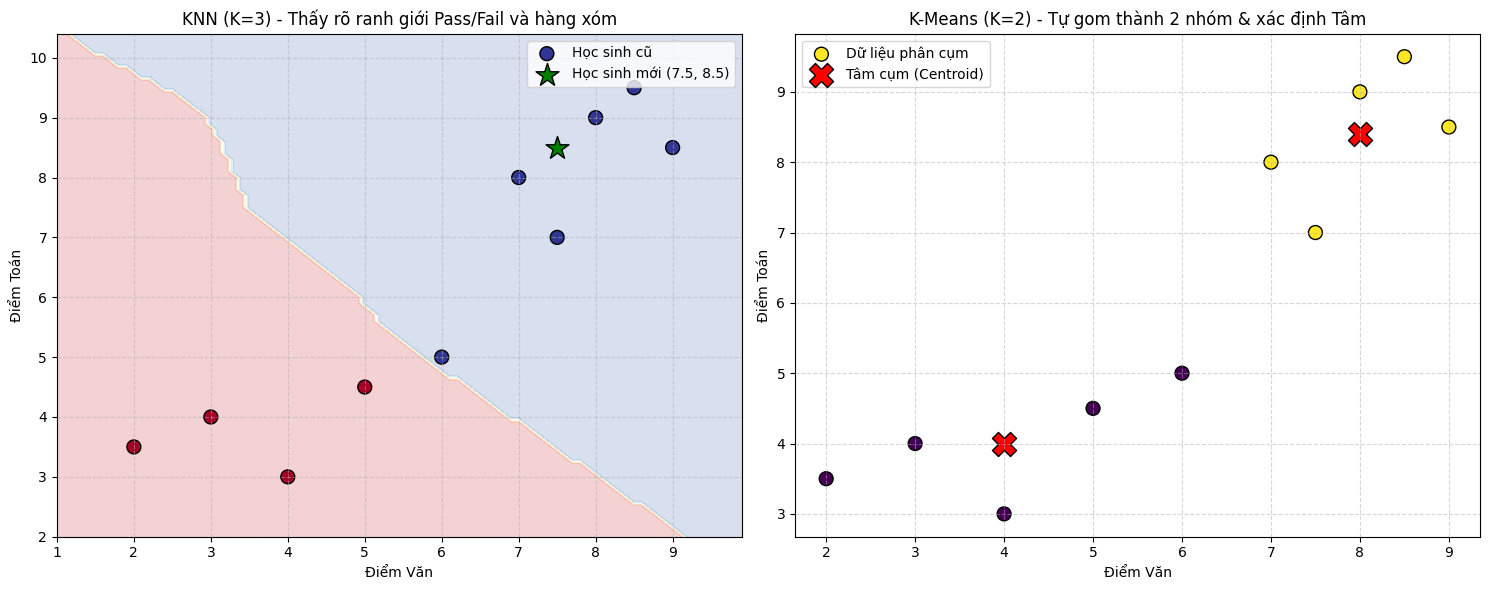

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

data = {
    'diemvan': [8, 7, 4, 9, 3, 8.5, 5, 7.5, 2, 6],
    'diemtoan': [9, 8, 3, 8.5, 4, 9.5, 4.5, 7, 3.5, 5],
    'ketqua': ['Pass', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass']
}
df = pd.DataFrame(data)
X = df[['diemvan', 'diemtoan']].values
# Chuyển nhãn text thành số (Pass: 1, Fail: 0) để vẽ đồ thị màu sắc
y = df['ketqua'].map({'Pass': 1, 'Fail': 0}).values

# Điểm của học sinh mới cần dự đoán/kiểm tra
hoc_sinh_moi = np.array([[7.5, 8.5]])

# Cấu hình khung vẽ đồ thị 2 bên
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ----------------------------------------------------
# ĐỒ THỊ 1: KNN (K = 3) - Dự đoán có nhãn
# ----------------------------------------------------
# Huấn luyện mô hình KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# Tạo lưới nền để vẽ ranh giới (Decision Boundary)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Vẽ vùng ranh giới phân lớp nền (Đỏ nhạt = Fail, Xanh nhạt = Pass)
ax1.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdYlBu)

# Vẽ các điểm học sinh cũ
scatter = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', s=100, label='Học sinh cũ')
# Vẽ học sinh mới (Ngôi sao màu xanh lá)
ax1.scatter(hoc_sinh_moi[0, 0], hoc_sinh_moi[0, 1], color='green', marker='*', s=300, edgecolor='k', label='Học sinh mới (7.5, 8.5)')

ax1.set_title("KNN (K=3) - Thấy rõ ranh giới Pass/Fail và hàng xóm", fontsize=12)
ax1.set_xlabel("Điểm Văn")
ax1.set_ylabel("Điểm Toán")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# ----------------------------------------------------
# ĐỒ THỊ 2: K-Means (K = 2) - Gom cụm không nhãn
# ----------------------------------------------------
# Huấn luyện mô hình K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Vẽ các điểm dữ liệu được tô màu tự động theo 2 cụm mà máy tự chia
ax2.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, edgecolor='k', label='Dữ liệu phân cụm')
# Vẽ vị trí các Tâm cụm (Dấu X màu đỏ lớn)
ax2.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=300, c='red', edgecolor='k', label='Tâm cụm (Centroid)')

ax2.set_title("K-Means (K=2) - Tự gom thành 2 nhóm & xác định Tâm", fontsize=12)
ax2.set_xlabel("Điểm Văn")
ax2.set_ylabel("Điểm Toán")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

# Hiển thị đồ thị
plt.tight_layout()
plt.show()


Nhãn cụm của các học sinh (-1 là điểm nhiễu): [ 0  0  0  0  0  1  1  1  1  1 -1 -1]


/var/folders/sn/gtzs5njd3fj7gkzz_3jd816w0000gn/T/ipykernel_12968/72870284.py:45: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, edgecolor='k' if marker=='o' else 'none', label=label_text)


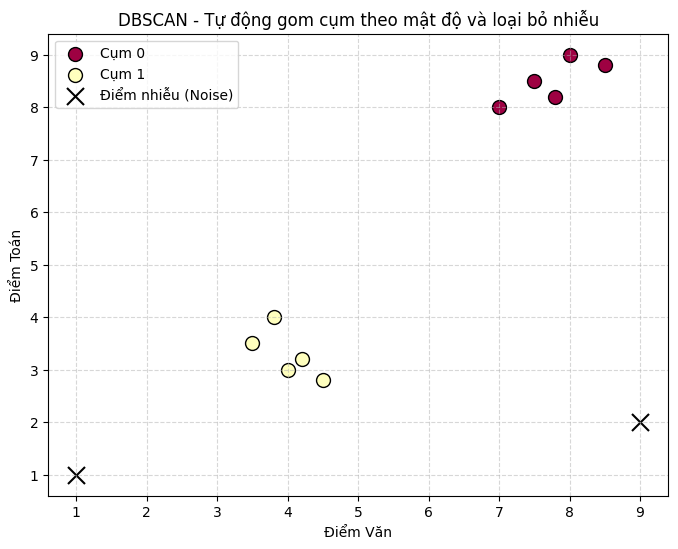

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# BƯỚC 1: Thu thập dữ liệu (Thêm một số học sinh có điểm cá biệt/nhiễu)
data = {
    'diemvan':  [8, 7.5, 8.5, 7, 7.8, 4, 3.5, 4.5, 3.8, 4.2,  1,  9], 
    'diemtoan': [9, 8.5, 8.8, 8, 8.2, 3, 3.5, 2.8, 4.0, 3.2,  1,  2]
}
# Lưu ý: Điểm (1,1) và (9,2) là các điểm cá biệt nằm rất xa các nhóm còn lại
df = pd.DataFrame(data)
X = df[['diemvan', 'diemtoan']].values

# BƯỚC 3 & 4: Lựa chọn mô hình và Tiến hành Huấn luyện
# Thiết lập bán kính eps = 1.5 và số điểm tối thiểu min_samples = 3
dbscan = DBSCAN(eps=1.5, min_samples=3)
labels = dbscan.fit_predict(X)

# BƯỚC 5: Kiểm chứng và Trực quan hóa kết quả
# Nhãn -1 đại diện cho điểm Nhiễu (Noise) do DBSCAN phát hiện
print("Nhãn cụm của các học sinh (-1 là điểm nhiễu):", labels)

# Vẽ đồ thị
plt.figure(figsize=(8, 6))

# Lấy danh sách các cụm duy nhất tìm được
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Màu đen dành cho điểm nhiễu (Noise)
        col = [0, 0, 0, 1]
        marker = 'x'
        label_text = 'Điểm nhiễu (Noise)'
        size = 150
    else:
        marker = 'o'
        label_text = f'Cụm {k}'
        size = 100

    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, edgecolor='k' if marker=='o' else 'none', label=label_text)

plt.title("DBSCAN - Tự động gom cụm theo mật độ và loại bỏ nhiễu")
plt.xlabel("Điểm Văn")
plt.ylabel("Điểm Toán")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


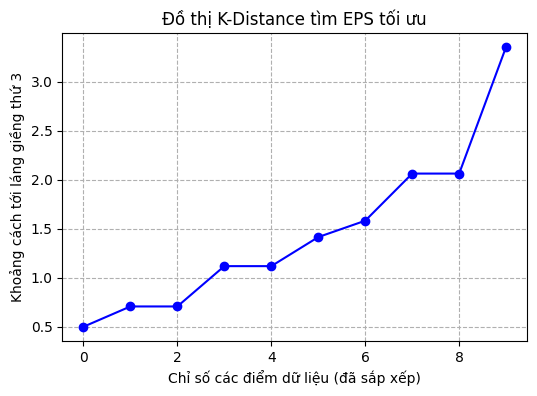

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# 1. Giả lập dữ liệu điểm số học sinh
data = {'diemvan': [8,7,4,8.5,3.5,7.5,4.5,9,2,8], 'diemtoan': [9,8,3,8.5,4,7,5,9.5,1,8.5]}
df = pd.DataFrame(data)
X = df.values

# 2. Định nghĩa số lượng láng giềng k (thường bằng tham số min_samples)
k = 3
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# 3. Sắp xếp khoảng cách tăng dần (lấy khoảng cách tới láng giềng xa nhất trong nhóm k)
distances = np.sort(distances[:, k-1], axis=0)

# 4. Vẽ đồ thị tìm điểm gãy (Elbow Point)
plt.figure(figsize=(6, 4))
plt.plot(distances, marker='o', color='b')
plt.title("Đồ thị K-Distance tìm EPS tối ưu")
plt.xlabel("Chỉ số các điểm dữ liệu (đã sắp xếp)")
plt.ylabel(f"Khoảng cách tới láng giềng thứ {k}")
plt.grid(True, linestyle='--')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==========================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU CÓ CHỨA NHIỄU
# ==========================================
# Giả lập dữ liệu học sinh giỏi (Pass), kém (Fail) 
# và cố tình chèn thêm 2 điểm NHIỄU nhập sai nhãn ở cuối.
data = {
    'diemvan':  [8.0, 7.0, 4.0, 8.5, 3.5, 9.0, 4.5, 7.5, 3.0, 8.2,   9.0, 8.8], 
    'diemtoan': [9.0, 8.0, 3.0, 8.8, 4.0, 9.5, 3.5, 8.5, 2.5, 8.0,   9.2, 8.6],
    'ketqua':   ['Pass','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Fail','Pass', 'Fail','Fail'] 
   
}
df = pd.DataFrame(data)
X = df[['diemvan', 'diemtoan']].values
y = df['ketqua'].values

print(f"Tổng số dữ liệu ban đầu: {len(df)} dòng.")

# ==========================================
# BƯỚC 2: DÙNG DBSCAN LÀM BỘ LỌC NHIỄU (NOISE FILTER)
# ==========================================
# Quét mật độ để tìm ra các điểm cá biệt
dbscan = DBSCAN(eps=1.2, min_samples=3)
dbscan_labels = dbscan.fit_predict(X)

# Tìm các vị trí KHÔNG PHẢI là nhiễu (nhãn DBSCAN khác -1)
mask_clean = (dbscan_labels != -1)

# Tạo tập dữ liệu mới đã được lọc sạch bụi bẩn
X_clean = X[mask_clean]
y_clean = y[mask_clean]

print(f"Số lượng điểm nhiễu bị phát hiện và xóa bỏ: {np.sum(~mask_clean)} dòng.")
print(f"Số lượng dữ liệu sạch còn lại: {len(X_clean)} dòng.\n")

# ==========================================
# BƯỚC 3: HUẤN LUYỆN KNN TRÊN TẬP DỮ LIỆU SẠCH
# ==========================================
# Chia dữ liệu sạch để train và test
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

# Khởi tạo KNN với K=1 (Lúc này K=1 cực kỳ an toàn vì không còn nhiễu để bẫy mô hình)
knn_clean = KNeighborsClassifier(n_neighbors=1)
knn_clean.fit(X_train, y_train)

# Đánh giá nhanh
y_pred = knn_clean.predict(X_test)
print(f"Độ chính xác của KNN sau khi được DBSCAN lọc nhiễu: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Thử dự đoán cho học sinh mới (7.5 Văn, 8.5 Toán) nằm gần khu vực nhiễu cũ
hoc_sinh_moi = np.array([[7.5, 8.5]])
du_doan = knn_clean.predict(hoc_sinh_moi)
print(f"Dự đoán cho học sinh mới: {du_doan[0]} (Đã ra kết quả chính xác!)")


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Dữ liệu gốc: Điểm Văn (đề dễ, điểm cao), Điểm Toán (đề khó, điểm thấp)
data = {
    'diemvan': [9.0, 8.5, 9.5, 9.0, 8.0],  # Trung bình quanh mốc 8.8
    'diemtoan': [5.0, 6.0, 4.5, 5.5, 8.0]  # Trung bình quanh mốc 5.8 (riêng bạn cuối là siêu nhân được 8)
}
df = pd.DataFrame(data)

# Tiến hành Standardization
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df), columns=['Z_van', 'Z_toan'])

print("--- DỮ LIỆU GỐC ---")
print(df)
print("\n--- DỮ LIỆU SAU KHI STANDARDIZATION (Z-SCORE) ---")
print(df_standardized.round(2))


--- DỮ LIỆU GỐC ---
   diemvan  diemtoan
0      9.0       5.0
1      8.5       6.0
2      9.5       4.5
3      9.0       5.5
4      8.0       8.0

--- DỮ LIỆU SAU KHI STANDARDIZATION (Z-SCORE) ---
   Z_van  Z_toan
0   0.39   -0.66
1  -0.59    0.17
2   1.37   -1.08
3   0.39   -0.25
4  -1.57    1.82
